# **CoinCoach - a Personal Finance Coach**

# 1. Problem Definition


*   Problem Statement : Build an AI powered financial coach that guides the users through their financial situations, plan their spendings wisely, set saving goals and make daya to day financial decisions based on their income, expenses and fiancial goals.

*   Audience : It is being built for students and young adults who want personalized guidance for managing their money but may have limited financial knowledge.

*   Tasks :
    1.  Create a budget : Given a user's income, expenses and spending habits generate a monthly budget and flag areas where they could have reduced unnecessary spending.
    2. Plan for a financial goal: Help a user create a savings plan for a specific goal like building an emergency fund, saving for a trip.
    3. Evaluate a financial decision: Given a user;s income, expenses and savings and a planned purchase assess how would this purchase affect their budget and suggest considerations or alternatives before making decisions




#2. Setup

## Installations

In [ ]:
!pip install -q -U langchain langgraph langsmith langchain-google-genai

## Importing libraries

In [ ]:
import os
import re
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from google.colab import userdata
from langsmith import Client
from langsmith import traceable, tracing_context
from typing import Optional
from langchain.agents import create_agent
import base64

##Model

I am using Google Gemini through Google AI Studio. I am going to use Gemini 3.5 Flash Lite for Perception and Gemini 3.6 Flash for reasoning.

In [ ]:
google_api_key =  userdata.get("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = google_api_key

In [ ]:
# Connecting to the Gemini model
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite",google_api_key=google_api_key)

In [ ]:
# Testing the model response
response = llm.invoke("hello!respond with a greeting.")
print(response.content)

[{'type': 'text', 'text': "Hello! It's great to hear from you. How can I help you today?", 'extras': {'signature': 'ErAFCq0FAWkUfROzfZ76PIvYTI5aN5KRXzZn9xwcMN+CpMznPOux8g/zkJ77Uzz1ZZ42wAZ2WAt2j43/CDdml57nZ2XHh1M7EgdFeCQkHRInDsijQKhadU0czWqWryNNRK854b8RoiDtomEmUDJh1N8yO6pJqj2wvnaF0nitXfUYKQIFST+dzhfo45X1vEyUDRP2WiBOBum7qtKGDRJjHd3dwbXzH6Vx10s/ULMEtLH1Be7CGyqTlouDzd2RLH1Gli1ohlq4HKltjpENiDfLFUaHhQFJdQIi5UcoBWnH4x8itHtBfsMPpWgpGQcrHjKmchb25wVvJ+d1Uo0C4WihZ3liM9DlF8txXHs2/uG/NPcxSElaKnEf51Y4cjxqxuSOsntPvtC75tz8Qtc2QoT0aOdzu/IJgYUS5z85ZnOeVX6d4wqvDBkqGNpYa5oKo0gEIkAM3QMFx6krvjZP1riSO0OV+LsSLtkn4f05seoxn4kLwwfYD2QcjQbEaJon/BaZVX3J0+bgkQ76mDodouHTy3OEOiaZ+c5HQUT8xR18+Q3puGVbyNP7ik2eQ5v8V3M8QGtKiOTyKnou63soYDssDyIFBsm8rPy2AHWiq0T7oz8NoaIK+zTbjEKmtyDIq8K9zn+hVGNpJL/TtNCHICCsyffLCOzEof6CUVY7Eq3N2MCqvDf9o0QQVcUMRtEIeoCMm+b56BgtFEZHlmlzzmCGz9vT6Qs7YWZr0OqEXKVLTVsIu3iu1fZU6tbJZn669C9LoPUcp7XmpZi2GH6I134poU3XQNGwozlNJRf98VWt+4AuXYwbNf/CFX/TPDKyfwWEhQYiSSvUg8Dnu9rYsLbd6cKO9c08OzzeNBirXWrMoQol+GpQMA8X

## Observability

In [ ]:
# LangSmith API key
if userdata.get('LANGSMITH_KEY'):
  print("Hooray! The LangSmith key is there.")
else:
  print("Oh darn, the LangSmith key isn't there.")

Hooray! The LangSmith key is there.


In [ ]:
langsmith_api_key = userdata.get('LANGSMITH_KEY')
os.environ["LANGSMITH_API_KEY"] = langsmith_api_key
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "CoinCoach_PersonalFinanceAgent"

In [ ]:
# Idnetifying the project
KEY = userdata.get('LANGSMITH_KEY')

client = Client(api_key=KEY)

try:
  projects = list(client.list_projects())
  print(f'API call succeeded. {len(projects)} projects found.')

except Exception as e:
  print('API call failed.')
  print(f'Details: {e}')

API call succeeded. 1 projects found.


In [ ]:
PROJECT_NAME = "CoinCoach_PersonalFinanceAgent"

client = Client(api_key=KEY)
project = client.create_project(project_name=PROJECT_NAME, upsert=True)

In [ ]:
try:
  projects = list(client.list_projects())

  has_project = any(getattr(obj, 'name', None) == PROJECT_NAME for obj in projects)
  print(f"LangSmith has project {PROJECT_NAME}? {'Yes' if has_project else 'No'}")

except Exception as e:
  print('API call failed.')
  print(f'Details: {e}')

LangSmith has project CoinCoach_PersonalFinanceAgent? Yes


## Tracing in LangSmith
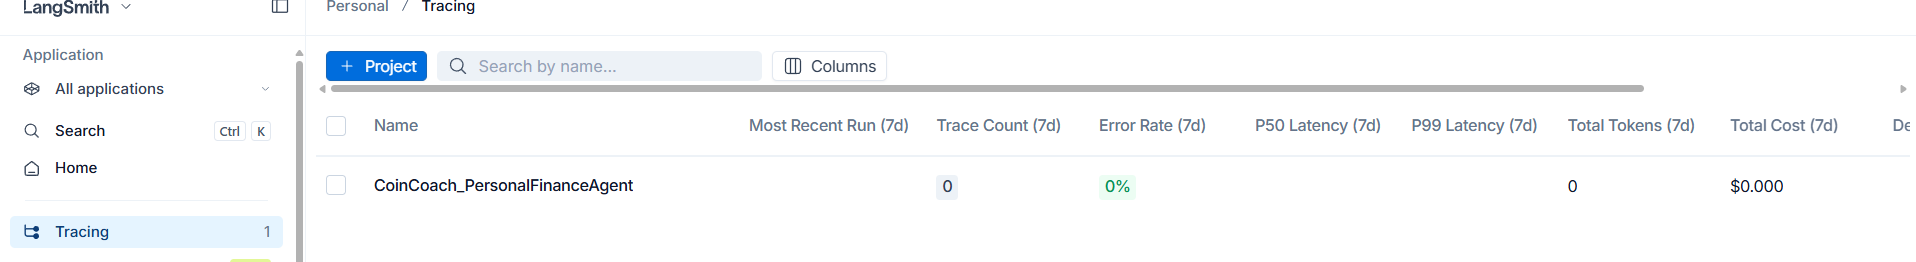

## Test creating a Trace in LangSmith

In [ ]:
@traceable
def task(prompt):
    return f"Responding to: {prompt}"

# tracing_context avoids environment variable issues with Colab
with tracing_context(client=client, project_name=PROJECT_NAME, enabled=True):
  task("Testing LangSmith traces from Google Colab")

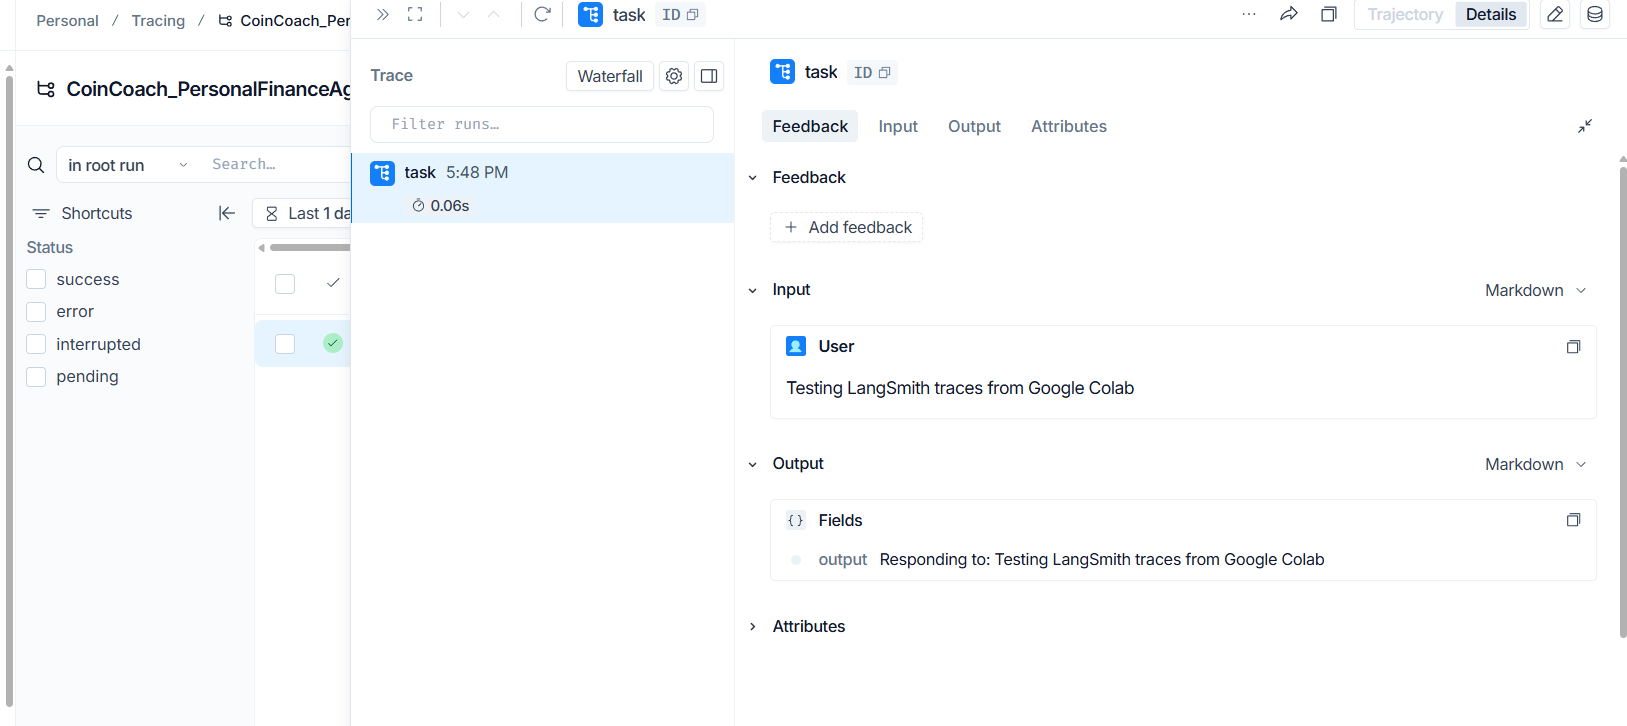

#3.  Data Design

The Pydantic schema represents the financial information that the agent needs to understand a user's financial situation. It captures income, expenses, savings, financial goals, other preferences that can be used to provide personalized financial guidance

In [ ]:
# Defining the schema
class PersonalFinanceState(BaseModel):
  monthly_income: Optional[float] = Field(
      default = None,
      description = "the user's total monthly income after taxes, if provided"
  )
  monthly_expenses: Optional[float] = Field(
      default = None,
      description = "the user's total monthly expenses, if provided"
  )
  current_savings: Optional[float] = Field(
      default = None,
      description = "the amount of money the user currently has saved, if provided"
  )
  savings_goal: Optional[str] = Field(
      default = None,
      description = "the user's stated financial savings goal, if one is mentioned"
  )
  savings_target: Optional[float] = Field(
      default = None,
      description = "the target amount of money the user wants to save, if provided"
  )
  goal_deadline: Optional[str] = Field(
      default = None,
      description = "the date or timeframe by which the user wants to achieve the financial goal"
  )
  debt: list[str] = Field(
        default_factory=list,
        description="Known debts or debt obligations mentioned by the user."
  )
  unclear_fields: list[str] = Field(
      default_factory = list,
      description = "fields where the information extracted from the user's input is missing, ambiguous or low confidence"
  )


#4. Perception

In [ ]:
#Instantiate the model
structured_model = llm.with_structured_output(PersonalFinanceState)

## Perception from text

In [ ]:
# Perception from text function
def perceive_text(raw_text:str)-> PersonalFinanceState:
  message = f"""
  Extract the user's financial information from the following text.
  Only extract information that is explicitly stated or reasonably clear.
  Do not invent missing information.
  If a field is missing or unclear, leave it as None or an empty list and add the field name to unclear_fields.
  User input:
  {raw_text}
  """
  return structured_model.invoke(message)

In [ ]:
# Testing the function
text_input = """
I earn $3000 per month after taxes.
My monthly expenses are $1000.
I currently have $2000 in savings.
My goal is to build an emergency fund of $6,000 within 12 months.
"""
text_state = perceive_text(text_input)
print(text_state.model_dump_json(indent=2))

{
  "monthly_income": 3000.0,
  "monthly_expenses": 1000.0,
  "current_savings": 2000.0,
  "savings_goal": "build an emergency fund",
  "savings_target": 6000.0,
  "goal_deadline": "12 months",
  "debt": [],
  "unclear_fields": []
}


## Perception from image

In [ ]:
# Perception from image function
from langchain_core.messages import HumanMessage
def perceive_image(
    image_path: str,
    context_note: str = ""
) -> PersonalFinanceState:
  """
  Extract financial info from an image
  """
  with open(image_path,"rb") as image_file:
    image_data = base64.b64encode(image_file.read()).decode("utf-8")

  message = HumanMessage(
      content = [
          {
              "type": "text",
              "text": f"""
              Extract financial information from this image.
              Identify information such as:
              - monthly income
              - monthly expense
              - current savings
              - savings goals
              - savings targets

              Only extract informationthat is visiblle in the image.
              Do not invent information.
              If information is missing, ambiguous or difficult to read,
              leave the appropriate field empty or None and add that field
              to unclear_fields.

              Additional context:
              {context_note}
              """
          },
          {
              "type": "image_url",
              "image_url": {
                  "url": f"data:image/jpeg;base64,{image_data}"
              }
          }
      ]
  )
  return structured_model.invoke([message])

The image I used for the below code is made by me in excel sheets

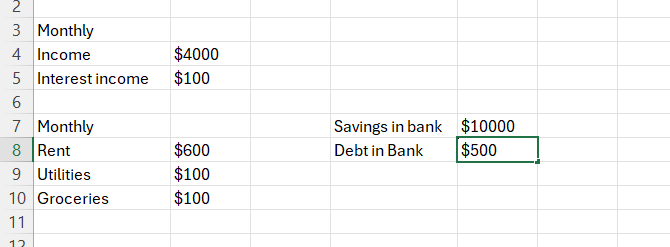

In [ ]:
# Testing the function
image_path = "/content/budget_hamshi.png"
image_state = perceive_image(
    image_path,
    context_note = "This image shows the user's monthly personal budget"
)
print(image_state.model_dump_json(indent=2))

{
  "monthly_income": 4100.0,
  "monthly_expenses": 800.0,
  "current_savings": 10000.0,
  "savings_goal": null,
  "savings_target": null,
  "goal_deadline": null,
  "debt": [
    "Debt in Bank: $500"
  ],
  "unclear_fields": [
    "savings_goal",
    "savings_target",
    "goal_deadline"
  ]
}


## Data Cleaning

Cleaning the extra spaces in the text and making it simple.

In [ ]:
# Cleaning function
def clean_text(raw_text:str) -> str:
  cleaned_text = raw_text.strip()
  cleaned_text = " ".join(cleaned_text.split())
  return cleaned_text

In [ ]:
# Perception from cleaned text input
def perceive_text(raw_text:str)-> PersonalFinanceState:
  cleaned_text = clean_text(raw_text)
  message = f"""
  Extract the user's financial information from the following text.
  Only extract information that is explicitly stated or reasonably clear.
  Do not invent missing information.
  If a field is missing or unclear, leave it as None or an empty list and add the field name to unclear_fields.
  User input:
  {cleaned_text}
  """
  return structured_model.invoke(message)

In [ ]:
text_input = """
My income is $3000 per month after taxes.
My monthly rent is $700 and utilities are $150.
I currently have $4000 in savings.
My goal is to build an emergency fund of $6,000 within 12 months.
"""
text_state = perceive_text(text_input)
print(text_state.model_dump_json(indent=2))

{
  "monthly_income": 3000.0,
  "monthly_expenses": 850.0,
  "current_savings": 4000.0,
  "savings_goal": "build an emergency fund",
  "savings_target": 6000.0,
  "goal_deadline": "12 months",
  "debt": [],
  "unclear_fields": []
}


## Data Filtering

Filtering out the user's input into different keyword fields

In [ ]:
# Filtering the user input into keywords mappings
def filter_financial_text(raw_text: str)-> str:
  financial_keywords = [
      "income",
      "salary",
      "earn",
      "expenses",
      "rent",
      "utility",
      "groceries",
      "dinning",
      "savings",
      "save",
      "debt",
      "loan",
      "goal",
      "budget",
      "spending",
      "subscritpion",
      "investment"
  ]

  sentences = raw_text.split(".")
  relevant_sentences = []
  for sentence in sentences:
    if any(keyword in sentence.lower() for keyword in financial_keywords):
      relevant_sentences.append(sentence.strip())
  return ". ".join(relevant_sentences)

In [ ]:
# Defining perception from filtered text function
def perceive_text(raw_text: str) -> PersonalFinanceState:
  cleaned_text = clean_text(raw_text)
  filtered_text = filter_financial_text(cleaned_text)
  message = f"""
    Extract the user's financial information from the following text.

    Only extract information that is explicitly stated or reasonably clear.
    Do not invent missing information.

    If a field is missing or unclear, leave it as None or an empty list
    and add the field name to unclear_fields.

    User input:
    {filtered_text}
    """
  return structured_model.invoke(message)

In [ ]:
# Testing the text input
text_input = """
My monthly rent is $700 and utilities are $150.
I currently have $4000 in savings.
My goal is to build an emergency fund of $3,000 within 6 months.
"""
text_state = perceive_text(text_input)
print(text_state.model_dump_json(indent=2))

{
  "monthly_income": null,
  "monthly_expenses": 850.0,
  "current_savings": 4000.0,
  "savings_goal": "build an emergency fund",
  "savings_target": 3000.0,
  "goal_deadline": "6 months",
  "debt": [],
  "unclear_fields": [
    "monthly_income"
  ]
}


#5.  Reasoning

Why the model used for reasoning need not be the same model used for perception?

Different models can be used for perception and reasoning as they both serve different purposes. The perception model is used for extracting structured financial information from text or images. The reasoning model uses the structured information to analyze the user's situation and generate a response.


In [ ]:
# Using a different model for reasoning
llm2 = llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash",google_api_key=google_api_key)

In [ ]:
# defining the create_agent
agent = create_agent(
    model=llm2,
    tools=[],
    system_prompt="""
    You are a personal finance coach.
    You will receive:
    1. A structured PersonalFinanceState conatining information extracted  from
    the user's financial information.
    2. A user request describing what they want help with.

    Your job is to provide practical financial guidance based inly on the information
    provided.

    Before providing the final answer, you MUST provide a visible and inspectable step-by-step
    reasoning summary. The reasoning summary must be included directly in your response so that
    it can be printed in colab and inspected in the LangSmith trace.

    Follow these steps:

    Step 1 - Identify relevant information:
    Identify the financial information from the PersonalFinanceState that is relevant
    to the user's request.

    Step 2 - Check missing or unclear information.
    Identify any fields that are missing, unclear or listed in unclesr_fields. Do not
    assume or invent values for missing information.

    Step 3 - Check for contradictions:
    Check whether any of the provided financial information is contradictory or inconsistent.
    If a contradiction exists, explicitly describe it rather than silently choosing one value.
    Consider relationships between fields when checking consistency.
    For example, if monthly expenses exceed monthly income, explicitly identify the resulting
    negative cash flow as financial inconsistency.

    Step 4 - Financial Assessment:
    Use the available information to explain the important calculations, comparisons,
    constraints or considerations relevant to the user's request.

    After completing the reasoning summary, provide the final answer.

    Use exactly this structure:

    REASONING SUMMARY

    Step 1 - Relevant Information:
    [Relevant information]

    Step 2 - Missing or unclear information
    [If there is Missing or unclear information, identify it.
    Otherwise state "No missing or unclear information"]

    Step 3 - Consistency Check
    [If there are contradictions, identify them.
    Otherwise, state "No contradictions"]

    Step 4 - Financial Assessment
    [Relevant calculations, comparisons or considerations]

    FINAL ANSWER:
    [Clear response to the user's request]

    If there are important missing or unclear fields, also include:

    CLARIFYING QUESTION:
    [Question needed to obtain the missing or unclear information]

    Only include CLARIFYING INFORMATION when additional information is actually needed.

    If the information is contradictory, clearly identify the contradictions and explain
    why it affects the answer.

    Do not invent financial information.

    Do not provide specific investment, tax or legal instructions.

    """
)

What is create_agent doing?

It creates the reasoning component of my personal finance coach. It connects the llm with the instruction in the system prompt and defines how the agent should process the structured information and respond to the user's request.

create_agent mainly provides the structure and instructions that guide the llm through reasoning about how the user's financial state and respond to the request.




In [ ]:
# Defining run_agent to get the response
def run_agent(
    user_state: PersonalFinanceState,
    user_request: str
) -> str:
  state_json = user_state.model_dump_json(indent=2)
  prompt = f"""
  Here is the user's structured financial information:
  {state_json}

  User request:
  {user_request}

  Use the structured financial information to answer the user's request.

  Your response must include the required visible reasoning summary followed
  by the final answer.
  """

  result = agent.invoke({
      "messages": [
          {
              "role": "user",
              "content": prompt
          }
      ]
  })
  return result["messages"][-1].content

## Test 1 : Ambiguous Input

In [ ]:
ambiguous_input = """
I earn around $3000 a month.
My expenses are about $1500.
I want to save a decent amount every month.
I also have some money saved already.
"""
ambiguous_state = perceive_text(ambiguous_input)
print(ambiguous_state.model_dump_json(indent=2))

{
  "monthly_income": 3000.0,
  "monthly_expenses": 1500.0,
  "current_savings": null,
  "savings_goal": "save a decent amount every month",
  "savings_target": null,
  "goal_deadline": null,
  "debt": [],
  "unclear_fields": [
    "current_savings",
    "savings_target",
    "goal_deadline"
  ]
}


In [ ]:
ambiguous_request = """
How much should I save each month?
"""

ambiguous_response = run_agent(
    ambiguous_state,
    ambiguous_request
)

In [ ]:
#Extract the text from LLM reponse
if isinstance(ambiguous_response, list):
  response_text = "\n".join(
      item["text"]
      for item in ambiguous_response
      if isinstance(item, dict) and item.get("type") == "text"
  )
else:
  response_text = ambiguous_response

#Add line breaks before each major section
response_text = re.sub(
    r"\s*(REASONING SUMMARY|Step [1-5] - [^\n:]+ :|FINAL ANSWER: |CLARIFYING QUESTION:)",
    r"\n\n\1\n",
    response_text
)

response_text = re.sub(r"\n{3,}", "\n\n", response_text)
print("="*70)
print("CoinCoach Response")
print("="*70)
print(response_text.strip())
print("\n" + "=" * 70)

CoinCoach Response
REASONING SUMMARY

Step 1 - Relevant Information:
- Monthly Income: $3,000.00
- Monthly Expenses: $1,500.00
- Outstanding Debt: $0.00
- Savings Goal: "save a decent amount every month"

Step 2 - Missing or unclear information:
- `current_savings`: Amount currently saved is missing/unclear.
- `savings_target`: Specific dollar amount targeted is missing/unclear.
- `goal_deadline`: Timeline for achieving specific savings milestones is missing/unclear.

Step 3 - Consistency Check:
- Monthly income ($3,000) exceeds monthly expenses ($1,500), resulting in a positive cash flow of $1,500 per month. No financial contradictions detected.

Step 4 - Financial Assessment:
- Net Cash Flow: $3,000 - $1,500 = $1,500 available each month.
- Guidelines: A common baseline is the 50/30/20 budget rule, which suggests putting at least 20% of monthly income toward savings ($600/month). 
- Maximum Capacity: Because expenses are 50% of income, you have the capacity to save up to $1,500 per m

For this case, the agent extracted the user's monthly income and expenses and calculated the available monthly surplus. It also identified that the user's current savings target and deasline were not provided.

The agent then used the available information and extracted information form the budget framework suggesting baseline percent that the user could save. It also asked a clarifying question about the user's current savings.

This was reasonable because the user's request was ambiguous, they wanted to save a "decent amount" but did not provide a target or timeline. Asking for additional information was an appropriate response.

## Test 2 : Missing Information

In [ ]:
missing_input = """
I earn around $3000 a month.
I want to save $5,000 for a trip in the next 3 months.
"""
missing_state = perceive_text(missing_input)
print(missing_state.model_dump_json(indent=2))

{
  "monthly_income": 3000.0,
  "monthly_expenses": null,
  "current_savings": null,
  "savings_goal": "trip",
  "savings_target": 5000.0,
  "goal_deadline": "next 3 months",
  "debt": [],
  "unclear_fields": [
    "monthly_expenses",
    "current_savings"
  ]
}


In [ ]:
missing_request = """
Can I reach my $5000 savings goal?
"""
missing_response = run_agent(
    missing_state,
    missing_request
)

In [ ]:
#Extract the text from LLM reponse
if isinstance(missing_response, list):
  response_text = "\n".join(
      item["text"]
      for item in missing_response
      if isinstance(item, dict) and item.get("type") == "text"
  )
else:
  response_text = missing_response

#Add line breaks before each major section
response_text = re.sub(
    r"\s*(REASONING SUMMARY|Step [1-5] - [^\n:]+ :|FINAL ANSWER: |CLARIFYING QUESTION:)",
    r"\n\n\1\n",
    response_text
)

response_text = re.sub(r"\n{3,}", "\n\n", response_text)
print("="*70)
print("CoinCoach Response")
print("="*70)
print(response_text.strip())
print("\n" + "=" * 70)

CoinCoach Response
REASONING SUMMARY

Step 1 - Relevant Information:
- Monthly Income: $3,000.00
- Savings Target: $5,000.00
- Savings Goal: Trip
- Goal Deadline: Next 3 months
- Debt: $0.00

Step 2 - Missing or unclear information
- `monthly_expenses` is missing/unclear.
- `current_savings` is missing/unclear.

Step 3 - Consistency Check
No contradictions found in the provided data.

Step 4 - Financial Assessment
- To reach $5,000 in 3 months starting from $0, you would need to save approximately $1,666.67 per month ($5,000 / 3).
- Over 3 months, your total earnings will be $9,000 ($3,000 x 3). 
- Saving $1,666.67 per month represents about 55.6% of your gross monthly income.
- Whether this is achievable depends on how much you currently have saved up toward this goal and what your actual monthly living expenses are. Without knowing these two factors, a definitive determination cannot be made.

FINAL ANSWER:
Mathematically, reaching your $5,000 goal in 3 months is possible because you

For this case, the agent extracted the user's income and the savings target, the trip as a goal and the time target as well. It then identifies that the user's current savings and expenses were not provided.

The agent then calculated that the user would need to save \$1666 per month to reach $5000 target in 3 months if the user is starting from 0. It also said that the reaching the goal would depend on the user's actual expenses and existing savings.

The agent's response was kind of reasonable, it did assume maybe the user would start saving from $0 but later asked for a clarifying question about the savings and expenses.

## Test 3 : Contradictory Information

In [ ]:
contradictory_input = """
I earn around $2000 a month.
My monthly expenses are $2500.
My current savings are $2000.
I want to save $10000 for an emergency fund in 6 months.
"""
contradictory_state = perceive_text(contradictory_input)
print(contradictory_state.model_dump_json(indent=2))

{
  "monthly_income": 2000.0,
  "monthly_expenses": 2500.0,
  "current_savings": 2000.0,
  "savings_goal": "emergency fund",
  "savings_target": 10000.0,
  "goal_deadline": "6 months",
  "debt": [],
  "unclear_fields": []
}


In [ ]:
contradictory_request = """
How should I increase my savings every month?
"""
contradictory_response = run_agent(
    contradictory_state,
    contradictory_request
)

In [ ]:
#Extract the text from LLM reponse
if isinstance(contradictory_response, list):
  response_text = "\n".join(
      item["text"]
      for item in contradictory_response
      if isinstance(item, dict) and item.get("type") == "text"
  )
else:
  response_text = contradictory_response

#Add line breaks before each major section
response_text = re.sub(
    r"\s*(REASONING SUMMARY|Step [1-5] - [^\n:]+ :|FINAL ANSWER: |CLARIFYING QUESTION:)",
    r"\n\n\1\n",
    response_text
)

response_text = re.sub(r"\n{3,}", "\n\n", response_text)
print("="*70)
print("CoinCoach Response")
print("="*70)
print(response_text.strip())
print("\n" + "=" * 70)

CoinCoach Response
REASONING SUMMARY

Step 1 - Relevant Information:
- Monthly Income: $2,000.00
- Monthly Expenses: $2,500.00
- Current Savings: $2,000.00
- Savings Goal: Emergency Fund
- Savings Target: $10,000.00
- Goal Deadline: 6 months
- Debt: None

Step 2 - Missing or unclear information
- A breakdown of specific monthly expenses (e.g., fixed vs. discretionary costs) is not provided, making it impossible to recommend specific budget cuts.

Step 3 - Consistency Check
- Financial Inconsistency: Monthly expenses ($2,500.00) exceed monthly income ($2,000.00), resulting in a negative monthly cash flow of -$500.00. 
- Goal Inconsistency: To reach a target of $10,000.00 from $2,000.00 in 6 months, you would need to save $8,000.00 total, or approximately $1,333.33 per month. With a current net deficit of -$500.00 per month, this timeline is not feasible under current conditions.

Step 4 - Financial Assessment
- Cash Flow Deficit: You are currently spending $500 more than you earn each m

In this case, the agent extracted the user's income, expenses, current savings, emergency fund target and deadline. It calculated the user's monthly expenses are $500 higher than their income, creating a monthly cash flow deficit.

The agent also calculated that the user would need an additional \$8000 to reach the $10000 target. It recognized that the current \$500 monthly deficit would need to be eliminated before the user could start saving towards the goal.

The agent was reasonable because it did not ignore the inconsistency between the income and expense. Instead, it identified the negative cash flow and explained the user would need to reduce their expenses or adjust goal timeline or increase income. It also asked for a more specific breakdown of expenses so that more specific guidance could be provided.